**Project** : Reducing Cost-to-Serve and Operational Inefficiencies in a Fashion & Beauty Supply Chain


# 01 Data Understanding, Cleaning & Exploratory Analysis


## Purpose of this notebook

Before we can make any operational recommendation, we need three things:

1. **A trustworthy dataset**:  no silent typing issues, no missing values misleading later aggregations, no duplicate SKUs inflating counts.
2. **A clear mental model of the business**: what each field represents operationally, and which fields will drive our KPIs.
3. **First-pass business intuition**: where is revenue concentrated? Which suppliers, routes, and product types dominate? Any immediate red flags?

This notebook delivers all three. It is written as a **client-facing walkthrough**: every non-trivial transformation is paired with a short rationale, so that a business stakeholder can follow the reasoning without reading the code line-by-line.

## Operational context (recap)

The client is a fashion & beauty brand selling **skincare, haircare, and cosmetics** through multiple channels. They operate with **5 suppliers, 3 carriers, 4 transport modes and 3 primary routes**. The business sponsors want to know *which combinations of supplier / route / mode / product are destroying margin* — and they want the answer in a form that non-analytical leaders can act on.

## Notebook structure

1. Data ingestion & schema review  
2. Data quality assessment (missing values, duplicates, type integrity)  
3. Cleaning & standardisation  
4. Feature engineering — derived operational metrics  
5. Initial exploratory insights (product / supplier / route / carrier lens)  
6. Persisted cleaned dataset for downstream notebooks

In [8]:
import pandas as pd

In [17]:
df = pd.read_csv("supply_chain_data.csv")
pd.set_option("display.max_columns", None)

df.head(20)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,3,Carrier B,4.444099,Supplier 4,Bangalore,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,8,Carrier C,3.880763,Supplier 3,Kolkata,14,314,24,1.085069,Pending,1.000911,Sea,Route A,134.369097
7,cosmetics,SKU7,42.958384,59,426,8496.103813,Female,93,17,11,1,Carrier B,2.348339,Supplier 4,Bangalore,22,564,1,99.466109,Fail,0.398177,Road,Route C,802.056312
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,7,Carrier C,3.404734,Supplier 4,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134
9,skincare,SKU9,64.015733,35,980,4971.145988,Unknown,14,27,83,1,Carrier A,7.166645,Supplier 2,Chennai,29,963,23,47.957602,Pending,3.844614,Rail,Route B,995.929461


In [43]:
# Checking whether there is any unexpected negative values or implausaible ranges

df.describe(include='all')

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
count,100,100,100.000000,100.000000,100.000000,100.000000,100,100.000000,100.000000,100.000000,100.000000,100,100.000000,100,100,100.000000,100.000000,100.00000,100.000000,100,100.000000,100,100,100.000000
unique,3,100,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,3,NaN,5,5,NaN,NaN,NaN,NaN,3,NaN,4,3,NaN
top,skincare,SKU0,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,Carrier B,NaN,Supplier 1,Kolkata,NaN,NaN,NaN,NaN,Pending,NaN,Road,Route A,NaN
freq,40,1,NaN,NaN,NaN,NaN,31,NaN,NaN,NaN,NaN,43,NaN,27,25,NaN,NaN,NaN,NaN,41,NaN,29,43,NaN
mean,NaN,NaN,49.462461,48.400000,460.990000,5776.048187,NaN,47.770000,15.960000,49.220000,5.750000,NaN,5.548149,NaN,NaN,17.080000,567.840000,14.77000,47.266693,NaN,2.277158,NaN,NaN,529.245782
std,NaN,NaN,31.168193,30.743317,303.780074,2732.841744,NaN,31.369372,8.785801,26.784429,2.724283,NaN,2.651376,NaN,NaN,8.846251,263.046861,8.91243,28.982841,NaN,1.461366,NaN,NaN,258.301696
min,NaN,NaN,1.699976,1.000000,8.000000,1061.618523,NaN,0.000000,1.000000,1.000000,1.000000,NaN,1.013487,NaN,NaN,1.000000,104.000000,1.00000,1.085069,NaN,0.018608,NaN,NaN,103.916248
25%,NaN,NaN,19.597823,22.750000,184.250000,2812.847151,NaN,16.750000,8.000000,26.000000,3.750000,NaN,3.540248,NaN,NaN,10.000000,352.000000,7.00000,22.983299,NaN,1.009650,NaN,NaN,318.778455
50%,NaN,NaN,51.239831,43.500000,392.500000,6006.352023,NaN,47.500000,17.000000,52.000000,6.000000,NaN,5.320534,NaN,NaN,18.000000,568.500000,14.00000,45.905622,NaN,2.141863,NaN,NaN,520.430444
75%,NaN,NaN,77.198228,75.000000,704.250000,8253.976921,NaN,73.000000,24.000000,71.250000,8.000000,NaN,7.601695,NaN,NaN,25.000000,797.000000,23.00000,68.621026,NaN,3.563995,NaN,NaN,763.078231


In [21]:
print('Shape :', df.shape)
print()
df.info()

Shape : (100, 24)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location

In [33]:
## Understanding the columns

Commercial = ["Product type", "SKU", "Price", "Number of products sold", "Revenue generated", "Customer demographics"]
Inventory = ["Availability", "Stock levels", "Order quantities", "Lead times"]
Suppleir_and_Manufacturing = ["Supplier name", "Location", "Lead time", "Production volums", "Manufacturing lead time", "Manufacturing costs"]
Logistics = ["Shipping times", "Shipping carriers", "Shipping costs", "Routes", "Transportation modes", "Costs"]
Quality = ["Inspection results", "Defect rates"]

# 02 Data Quality Assessment

In [31]:
# 2.1 Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing if len(missing) else '  (none)')

Columns with missing values:
  (none)


In [37]:
# 2.2 Duplicates - at SKU level we expect uniqueness (AN SKU is a unique identifier for a specific product (and its variant))
print('Duplicate rows (full row):     ', df.duplicated().sum())
print('Duplicate SKUs:                ', df['SKU'].duplicated().sum())

Duplicate rows (full row):      0
Duplicate SKUs:                 0


In [41]:
# 2.3 Categorical integrity — look at cardinality and top values for text columns. 
## I.E. a quick audit of how many distinct values each column has and what the most common value is
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print(f'{c:<25s}  unique={df[c].nunique():<4d}  top={df[c].mode().iloc[0]!r}')

Product type               unique=3     top='skincare'
SKU                        unique=100   top='SKU0'
Customer demographics      unique=4     top='Unknown'
Shipping carriers          unique=3     top='Carrier B'
Supplier name              unique=5     top='Supplier 1'
Location                   unique=5     top='Kolkata'
Inspection results         unique=3     top='Pending'
Transportation modes       unique=4     top='Road'
Routes                     unique=3     top='Route A'


**Data quality verdict:** The dataset is clean in absolute terms: no missing values, no duplicates, and all numeric ranges are operationally plausible (no negative costs, defect rates within `[0, 100]`, etc.). The work ahead is therefore **standardisation and enrichment** rather than repair.

## 03 Cleaning and Standardisation

Two things to watch for during cleaning:

- The dataset carries **two lead-time fields** (`Lead times` — order-to-shelf, and `Lead time` — supplier side). We will rename these to remove ambiguity.
- The field simply called `Costs` is a generic "transportation / logistics cost" per order. We will rename it to `transport_cost_total` to distinguish from `shipping_costs` (per-unit shipping cost).

We will:

- Normalise column names to `snake_case` for downstream ergonomics.
- Rename ambiguous fields (`Lead times` vs `Lead time`, `Costs`).
- Ensure categorical text is consistently cased / stripped.

In [51]:
# 3.1 Rename fields — explicit, readable, unambiguous
rename_map = {
    'Product type':          'product_type',
    'SKU':                   'sku',
    'Price':                 'price',
    'Availability':          'availability',
    'Number of products sold': 'units_sold',
    'Revenue generated':     'revenue',
    'Customer demographics': 'customer_segment',
    'Stock levels':          'stock_levels',
    'Lead times':            'order_lead_time',       # order-to-customer
    'Order quantities':      'order_quantity',
    'Shipping times':        'shipping_time_days',
    'Shipping carriers':     'shipping_carrier',
    'Shipping costs':        'shipping_cost',
    'Supplier name':         'supplier',
    'Location':              'supplier_location',
    'Lead time':             'supplier_lead_time',    # supplier-side
    'Production volumes':    'production_volume',
    'Manufacturing lead time': 'manufacturing_lead_time',
    'Manufacturing costs':   'manufacturing_cost',
    'Inspection results':    'inspection_result',
    'Defect rates':          'defect_rate',
    'Transportation modes':  'transport_mode',
    'Routes':                'route',
    'Costs':                 'transport_cost_total',
}
df = df.rename(columns=rename_map)
df.columns.tolist()

['product_type',
 'sku',
 'price',
 'availability',
 'units_sold',
 'revenue',
 'customer_segment',
 'stock_levels',
 'order_lead_time',
 'order_quantity',
 'shipping_time_days',
 'shipping_carrier',
 'shipping_cost',
 'supplier',
 'supplier_location',
 'supplier_lead_time',
 'production_volume',
 'manufacturing_lead_time',
 'manufacturing_cost',
 'inspection_result',
 'defect_rate',
 'transport_mode',
 'route',
 'transport_cost_total']

In [54]:
# 3.2 Tidy categorical text
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

# Title-case where it reads nicer
df['product_type']     = df['product_type'].str.title()
df['customer_segment'] = df['customer_segment'].str.title()
df['inspection_result'] = df['inspection_result'].str.title()
df['transport_mode']   = df['transport_mode'].str.title()

df[['product_type', 'supplier', 'supplier_location', 'transport_mode', 'route', 'inspection_result']].head()

,product_type,supplier,supplier_location,transport_mode,route,inspection_result
0,Haircare,Supplier 3,Mumbai,Road,Route B,Pending
1,Skincare,Supplier 3,Mumbai,Road,Route B,Pending
2,Haircare,Supplier 1,Mumbai,Air,Route C,Pending
3,Skincare,Supplier 5,Kolkata,Rail,Route A,Fail
4,Skincare,Supplier 1,Delhi,Air,Route A,Fail


## 04 Feature Engineering: Derived Operational Metrics

Raw columns are not decision-ready. We build the **derived metrics** that will power the KPI framework in notebook 02 and the ML models in notebook 03.

| Derived feature | Definition | Why we need it |
|---|---|---|
| `cost_to_serve` | `(manufacturing_cost + shipping_cost) * units_sold` | Total operational cost of serving a given SKU |
| `cost_to_serve_per_unit` | `manufacturing_cost + shipping_cost` | Comparable across high/low volume SKUs |
| `gross_margin` | `revenue − cost_to_serve` | Bottom-line contribution |
| `gross_margin_pct` | `gross_margin / revenue` | Profitability %, comparable across price points |
| `revenue_per_unit` | `revenue / units_sold` | Effective realised price |
| `inspection_pass` | `1` if `Pass`, `0` if `Fail`, `NaN` if `Pending` | Binary quality outcome |
| `is_high_defect` | `1` if `defect_rate` > median of dataset | Target variable for ML model in nb 03 |
| `late_flag` | `1` if `shipping_time_days > supplier_lead_time`, else `0` | Proxy for late delivery |

In [59]:
# 4.1 Cost-to-serve and margin
df['cost_to_serve_per_unit'] = df['manufacturing_cost'] + df['shipping_cost']
df['cost_to_serve']          = df['cost_to_serve_per_unit'] * df['units_sold']
df['gross_margin']           = df['revenue'] - df['cost_to_serve']
df['gross_margin_pct']       = df['gross_margin'] / df['revenue']
df['revenue_per_unit']       = df['revenue'] / df['units_sold']

# 4.2 Quality flags
df['inspection_pass'] = df['inspection_result'].map({'Pass': 1, 'Fail': 0})   # Pending -> NaN
df['is_high_defect']  = (df['defect_rate'] > df['defect_rate'].median()).astype(int)

# 4.3 Delivery timeliness proxy
df['late_flag'] = (df['shipping_time_days'] > df['supplier_lead_time']).astype(int)

df[['product_type','units_sold','revenue','cost_to_serve','gross_margin_pct','defect_rate','is_high_defect','late_flag']].head()

,product_type,units_sold,revenue,cost_to_serve,gross_margin_pct,defect_rate,is_high_defect,late_flag
0,Haircare,802,8661.996792,39487.634007,-3.558722,0.226410,0,0
1,Skincare,736,7460.900065,31893.340982,-3.274731,4.854068,1,0
2,Haircare,8,9577.749626,309.939989,0.967640,4.580593,1,0
3,Skincare,83,7766.836426,3100.407727,0.600815,4.746649,1,0
4,Skincare,871,2686.505152,83577.422116,-30.110092,3.145580,1,1


## 05 Initial Exploratory Data Analysis

We look through **four operational lenses**: product, supplier, logistics (route × mode × carrier), and quality. Each view is paired with a short business takeaway.

### Product-type lens: where is revenue and margin concentrated?

In [63]:
by_product = df.groupby('product_type').agg(
    skus            = ('sku', 'count'),
    units_sold      = ('units_sold', 'sum'),
    revenue         = ('revenue', 'sum'),
    cost_to_serve   = ('cost_to_serve', 'sum'),
    gross_margin    = ('gross_margin', 'sum'),
    avg_defect_rate = ('defect_rate', 'mean'),
).round(1)
by_product['margin_pct'] = (by_product['gross_margin'] / by_product['revenue'] * 100).round(1)
by_product.sort_values('revenue', ascending=False)

,skus,units_sold,revenue,cost_to_serve,gross_margin,avg_defect_rate,margin_pct
product_type,,,,,,,
Skincare,40,20731,241628.2,1126036.2,-884408.0,2.3,-366.0
Haircare,34,13611,174455.4,761496.5,-587041.1,2.5,-336.5
Cosmetics,26,11757,161521.3,580593.3,-419072.0,1.9,-259.5


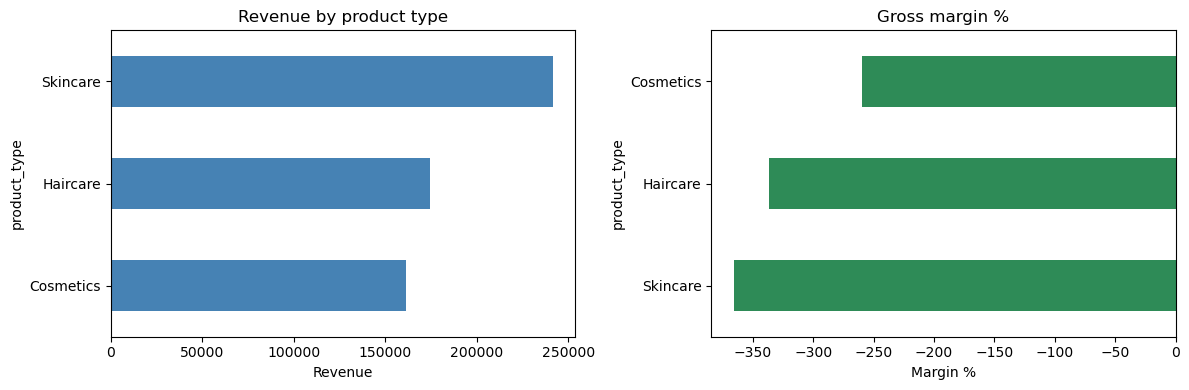

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

by_product['revenue'].sort_values().plot(
    kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Revenue by product type')
ax[0].set_xlabel('Revenue')

by_product['margin_pct'].sort_values().plot(
    kind='barh', ax=ax[1], color='seagreen')
ax[1].set_title('Gross margin %')
ax[1].set_xlabel('Margin %')

plt.tight_layout(); plt.show()

> **Insight: product mix:** Revenue and margin concentration are **not aligned**. The highest-revenue product type does not have the highest margin percentage. That is our first signal that volume and profitability are being driven by different operational forces — and that cost-to-serve is not uniform across the portfolio. We will quantify this gap in notebook 02.

### Supplier lens: reliability vs cost

In [71]:
by_supplier = df.groupby('supplier').agg(
    skus                     = ('sku', 'count'),
    avg_manufacturing_cost   = ('manufacturing_cost', 'mean'),
    avg_lead_time            = ('supplier_lead_time', 'mean'),
    lead_time_variability    = ('supplier_lead_time', 'std'),
    avg_defect_rate          = ('defect_rate', 'mean'),
    inspection_pass_rate     = ('inspection_pass', 'mean'),
).round(2)
by_supplier.sort_values('avg_defect_rate', ascending=False)

,skus,avg_manufacturing_cost,avg_lead_time,lead_time_variability,avg_defect_rate,inspection_pass_rate
supplier,,,,,,
Supplier 5,18,44.77,18.06,9.03,2.67,0.30
Supplier 3,15,43.63,20.13,8.28,2.47,0.40
Supplier 2,22,41.62,18.55,9.82,2.36,0.38
Supplier 4,18,62.71,15.22,7.92,2.34,0.00
Supplier 1,27,45.25,14.78,8.55,1.80,0.68


> **Insight — suppliers:** Defect rates and lead-time variability differ meaningfully between suppliers. Combined with differing manufacturing costs, this is the core tension for procurement: cheapest is not always most reliable. Notebook 03 will formalise this into a **K-means segmentation** and plot suppliers on a strategic Kraljic-style map.

### Logistics lens: carrier, route, transport mode

In [78]:
by_carrier = df.groupby('shipping_carrier').agg(
    shipments      = ('sku', 'count'),
    avg_ship_cost  = ('shipping_cost', 'mean'),
    avg_ship_time  = ('shipping_time_days', 'mean'),
    late_rate      = ('late_flag', 'mean'),
).round(2).sort_values('avg_ship_cost', ascending=False)
by_carrier

,shipments,avg_ship_cost,avg_ship_time,late_rate
shipping_carrier,,,,
Carrier C,29,5.60,6.03,0.10
Carrier A,28,5.55,6.14,0.18
Carrier B,43,5.51,5.30,0.14


In [80]:
by_route_mode = (df.groupby(['route', 'transport_mode'])
                   .agg(avg_ship_cost=('shipping_cost', 'mean'),
                        avg_ship_time=('shipping_time_days', 'mean'),
                        shipments=('sku', 'count'))
                   .round(2)
                   .reset_index())
by_route_mode.sort_values('avg_ship_cost', ascending=False).head(10)

,route,transport_mode,avg_ship_cost,avg_ship_time,shipments
11,Route C,Sea,7.55,7.25,4
0,Route A,Air,7.06,5.27,11
9,Route C,Rail,6.28,7.33,3
5,Route B,Rail,6.27,6.64,11
2,Route A,Road,5.61,5.36,11
6,Route B,Road,5.53,4.77,13
10,Route C,Road,5.41,3.20,5
4,Route B,Air,5.27,5.29,7
8,Route C,Air,5.25,4.75,8
1,Route A,Rail,4.67,6.36,14


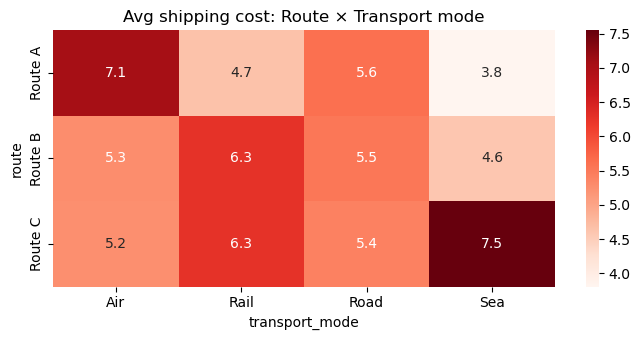

In [100]:
import seaborn as sns

pivot_cost = df.pivot_table(index='route', columns='transport_mode',
                             values='shipping_cost', aggfunc='mean')
plt.figure(figsize=(7, 3.5))
sns.heatmap(pivot_cost, annot=True, fmt='.1f', cmap='Reds')
plt.title('Avg shipping cost: Route × Transport mode')
plt.tight_layout()
plt.show()

> **Insight — logistics:** Cost per shipment varies materially across route–mode combinations. Some routes are demonstrably cheaper by rail or sea than by road, without a proportional increase in shipping time. This is our first explicit optimisation lever for notebook 04 (Recommendation R2).

### Quality lens: defects and inspection outcomes

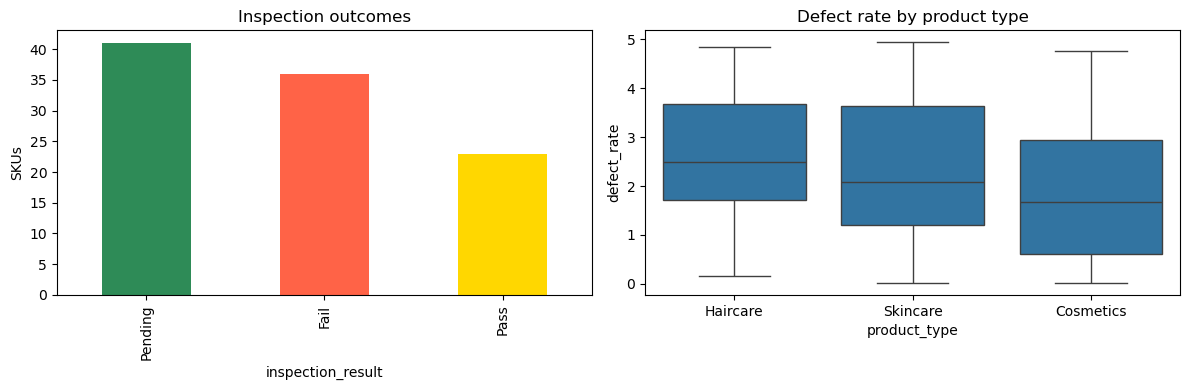

In [104]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['inspection_result'].value_counts().plot(
    kind='bar', ax=ax[0], color=['seagreen','tomato','gold'])
ax[0].set_title('Inspection outcomes')
ax[0].set_ylabel('SKUs')

sns.boxplot(data=df, x='product_type', y='defect_rate', ax=ax[1])
ax[1].set_title('Defect rate by product type')

plt.tight_layout()
plt.show()

> **Insight — quality:** A non-trivial share of inspections are `Pending` — meaning we have a blind spot in quality reporting. Additionally, one product type shows a clearly wider defect-rate distribution, pointing to a category-specific quality issue rather than a universal one. This will shape the predictive model target in notebook 03.

## 07 Persist Cleaned Dataset

In [110]:
df.to_csv("clean_data.csv", index=False)